In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

In [66]:
#Reading the first 5 rows of the dataset
pd.set_option('display.max_columns', None)
data = pd.read_csv("blood_pressure_global_dataset.csv")
data.head()

,Patient_ID,Year,Country,WHO_Region,Income_Level,Currency,ISO2_Country_Code,Age,Age_Group,Sex,BMI,BMI_Category,Smoking_Status,Alcohol_Use,Physical_Activity,Diet_Salt_Intake,Stress_Level,Diabetes,Family_Hx_Hypertension,Systolic_BP_mmHg,Diastolic_BP_mmHg,Pulse_Pressure_mmHg,Mean_Arterial_Pressure,Heart_Rate_bpm,BP_Category,Is_Hypertensive,Hypertension_Aware,On_Treatment,BP_Controlled,Country_HTN_Prevalence_pct,Measurement_Time,Measurement_Arm,Measurement_Setting,Measurement_Device
0,BP-00001,2000,Papua New Guinea,Western Pacific,Lower-Middle Income,PGK,pg,34,Adult (30-39),Male,23.1,Normal,Non-Smoker,NaN,Moderate,Moderate,Moderate,No,No,111.1,76.4,34.7,88.0,81,Normal,0,NaN,No,No,38,Morning,Right,Home,Mercury Sphygmomanometer
1,BP-00002,2022,Uganda,Africa,Low Income,UGX,ug,3,Early Childhood (1-5),Female,17.2,Underweight,Non-Smoker,NaN,Sedentary,Moderate,High,No,No,78.6,57.6,21.0,64.6,103,Hypotension (Low),0,NaN,No,No,47,Morning,Left,Pharmacy,Wrist Digital
2,BP-00003,2024,Kenya,Africa,Lower-Middle Income,KES,ke,29,Young Adult (19-29),Male,21.8,Normal,Non-Smoker,Occasional,Moderate,Moderate,Moderate,No,No,123.9,74.1,49.8,90.7,63,Elevated,0,NaN,No,No,42,Morning,Right,Clinical/Hospital,Automated Oscillometric
3,BP-00004,2014,Thailand,South-East Asia,Upper-Middle Income,THB,th,53,Middle-Aged Senior (50-59),Male,23.7,Normal,Ex-Smoker,Moderate,Light,Moderate,Moderate,No,Yes,150.1,76.2,73.9,100.8,87,Hypertension Stage 2,1,No,No,No,32,Afternoon,Right,Community Screening,Automated Oscillometric
4,BP-00005,2001,India,South-East Asia,Lower-Middle Income,INR,in,11,Early Adolescence (11-15),Female,16.2,Underweight,Non-Smoker,NaN,Light,Low,High,No,Unknown,94.6,66.7,27.9,76.0,82,Normal,0,NaN,No,No,29,Evening,Right,Home,Automated Oscillometric


In [67]:
#Checking my columns and names
data.columns

Index(['Patient_ID', 'Year', 'Country', 'WHO_Region', 'Income_Level',
       'Currency', 'ISO2_Country_Code', 'Age', 'Age_Group', 'Sex', 'BMI',
       'BMI_Category', 'Smoking_Status', 'Alcohol_Use', 'Physical_Activity',
       'Diet_Salt_Intake', 'Stress_Level', 'Diabetes',
       'Family_Hx_Hypertension', 'Systolic_BP_mmHg', 'Diastolic_BP_mmHg',
       'Pulse_Pressure_mmHg', 'Mean_Arterial_Pressure', 'Heart_Rate_bpm',
       'BP_Category', 'Is_Hypertensive', 'Hypertension_Aware', 'On_Treatment',
       'BP_Controlled', 'Country_HTN_Prevalence_pct', 'Measurement_Time',
       'Measurement_Arm', 'Measurement_Setting', 'Measurement_Device'],
      dtype='object')

In [68]:
#Checking categorical columns
data.nunique()

Patient_ID                    8000
Year                            26
Country                         86
WHO_Region                       6
Income_Level                     4
Currency                        81
ISO2_Country_Code               86
Age                            110
Age_Group                       12
Sex                              2
BMI                            289
BMI_Category                     4
Smoking_Status                   3
Alcohol_Use                      3
Physical_Activity                5
Diet_Salt_Intake                 3
Stress_Level                     4
Diabetes                         2
Family_Hx_Hypertension           3
Systolic_BP_mmHg              1175
Diastolic_BP_mmHg              704
Pulse_Pressure_mmHg            952
Mean_Arterial_Pressure         778
Heart_Rate_bpm                 100
BP_Category                      6
Is_Hypertensive                  2
Hypertension_Aware               2
On_Treatment                     2
BP_Controlled       

In [69]:
#Checking the information in the dataset i.e the columns, null values, datattypes etc
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  8000 non-null   object 
 1   Year                        8000 non-null   int64  
 2   Country                     8000 non-null   object 
 3   WHO_Region                  8000 non-null   object 
 4   Income_Level                8000 non-null   object 
 5   Currency                    8000 non-null   object 
 6   ISO2_Country_Code           8000 non-null   object 
 7   Age                         8000 non-null   int64  
 8   Age_Group                   8000 non-null   object 
 9   Sex                         8000 non-null   object 
 10  BMI                         8000 non-null   float64
 11  BMI_Category                8000 non-null   object 
 12  Smoking_Status              8000 non-null   object 
 13  Alcohol_Use                 3748 

In [70]:
#printing the column with null values
null= data.isnull().sum()
print(null[null>0])

Alcohol_Use           4252
Hypertension_Aware    3648
dtype: int64


In [71]:
print(data['Hypertension_Aware'].unique())
print(data['Alcohol_Use'].unique())

[nan 'No' 'Yes']
[nan 'Occasional' 'Moderate' 'Heavy']


In [72]:
data["Hypertension_Aware"] = data["Hypertension_Aware"].fillna("Unknown")
data["Alcohol_Use"] = data["Alcohol_Use"].fillna("Unknown")
nulls = data.isnull().sum()
print(nulls[nulls>0])

Series([], dtype: int64)


<Figure size 1200x800 with 0 Axes>

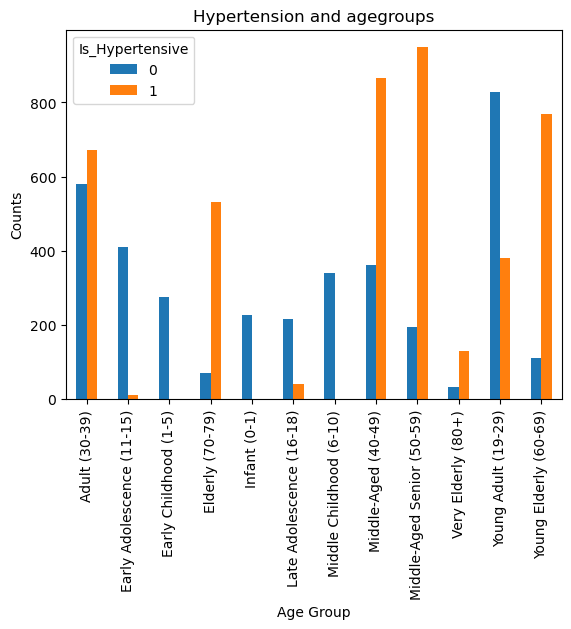

In [73]:
df1=data.groupby(["Age_Group", "Is_Hypertensive"])['WHO_Region'].count()
plt.figure(figsize=(12,8))
df1.unstack().plot(kind='bar')
plt.xlabel('Age Group')
plt.ylabel("Counts")
plt.title("Hypertension and agegroups");

Middle age  senior group of (50-59) have a high number of about (900) individuals with hypertension followed (40-49) years and young elderly of (age 60-69). Whereas Infants, early childhood, 	Early Adolesence have few to cases of diabetes.

<Axes: >

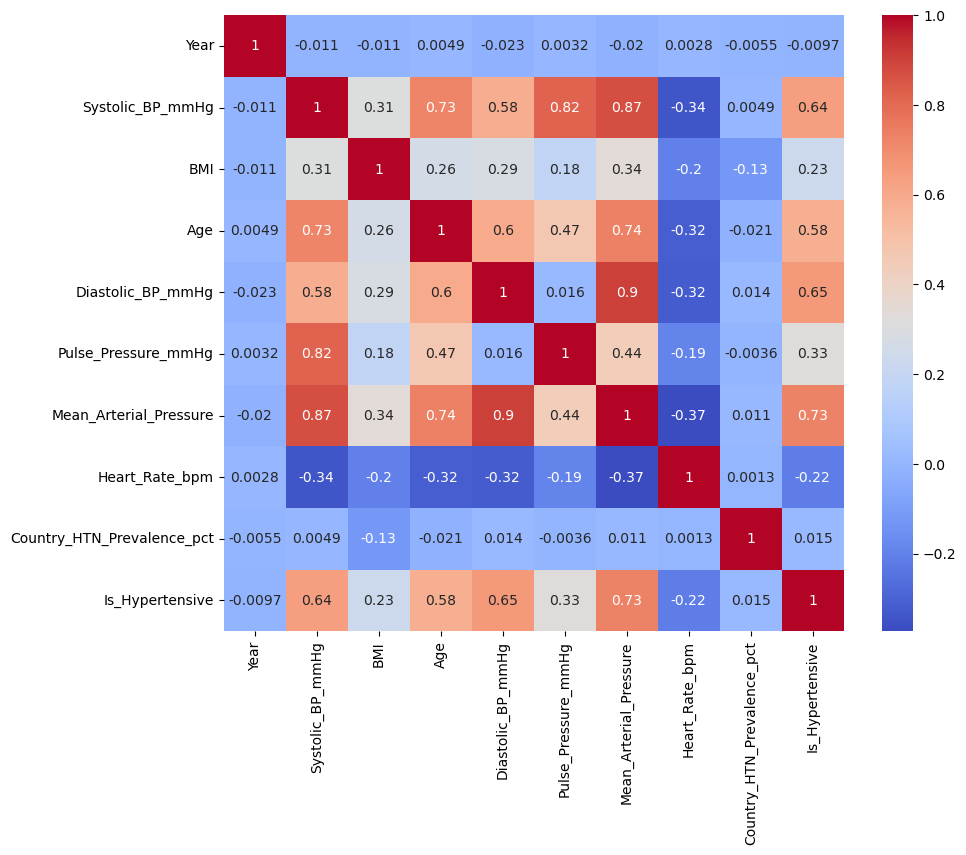

In [74]:
plt.figure(figsize=(10, 8))
df3= ["Year", "Systolic_BP_mmHg", "BMI", "Age", "Diastolic_BP_mmHg", "Pulse_Pressure_mmHg", "Mean_Arterial_Pressure", "Heart_Rate_bpm", "Country_HTN_Prevalence_pct", "Is_Hypertensive"]
df_subset=data[df3]
sns.heatmap(data = df_subset.corr(), annot= True, cmap = 'coolwarm')

''

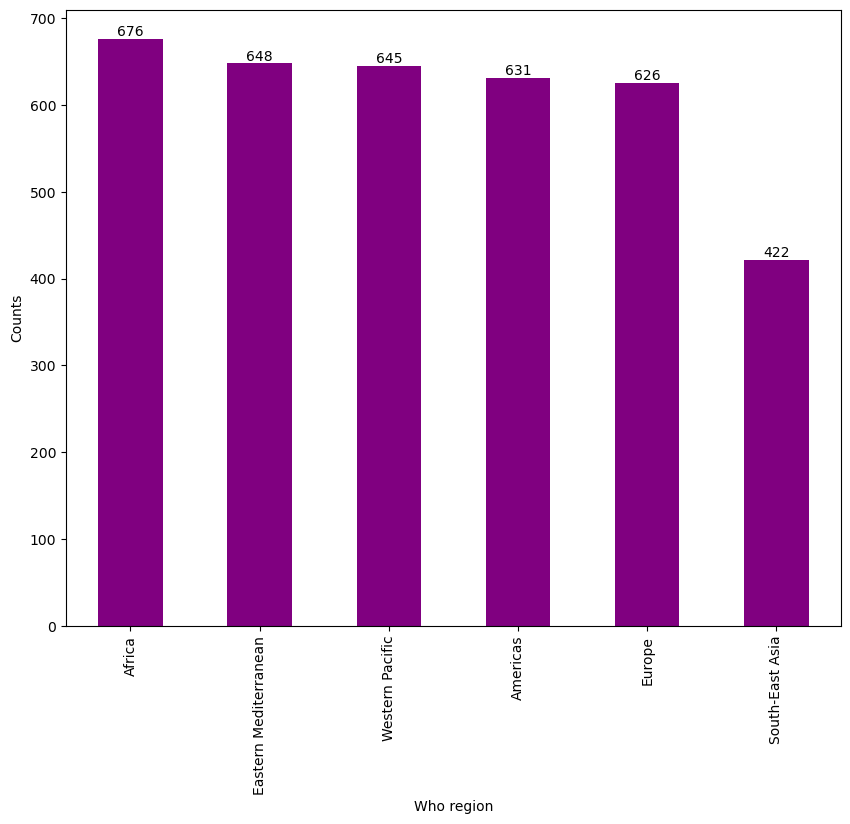

In [75]:
plt.figure(figsize=(10,8))
df2 = data[data['Is_Hypertensive']== 0].groupby("WHO_Region").size().sort_values(ascending=False)
df2.plot(kind='bar', color='purple')
plt.ylabel("Counts")
plt.xlabel("Who region")
for i, rate in enumerate(df2):plt.text(i, rate, f"{rate}", ha='center', va='bottom', fontsize=10)
;

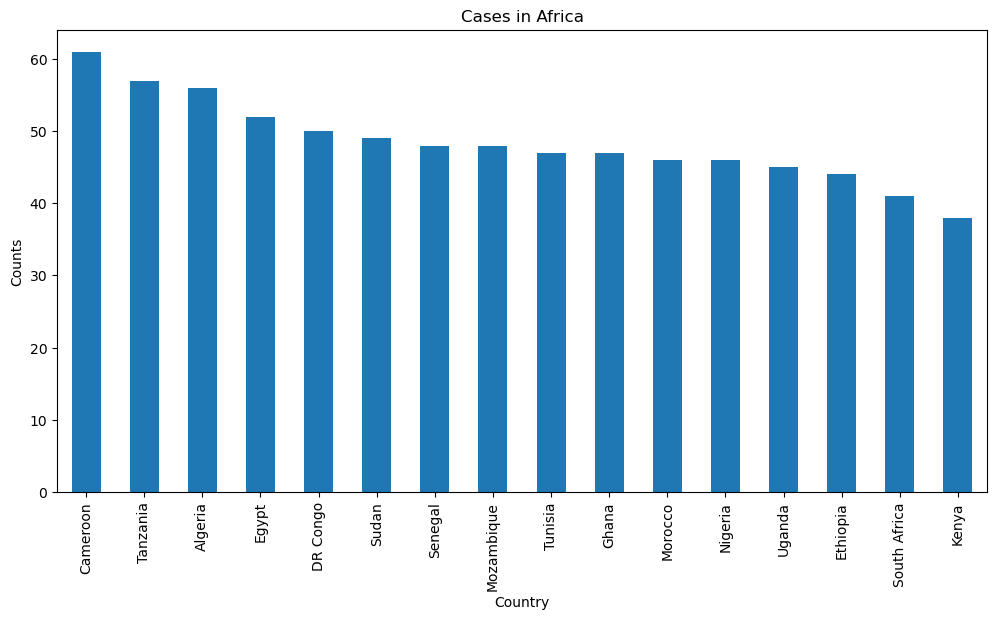

In [76]:
df4 = data[(data['WHO_Region'] == "Africa") & (data['Is_Hypertensive']==1)]
df5 = df4.groupby("Country").size()
plt.figure(figsize=(12,6))
df5.sort_values(ascending=False).plot(kind='bar')
plt.title('Cases in Africa')
plt.ylabel('Counts');

Western pacific has the highest number of people with diabetes

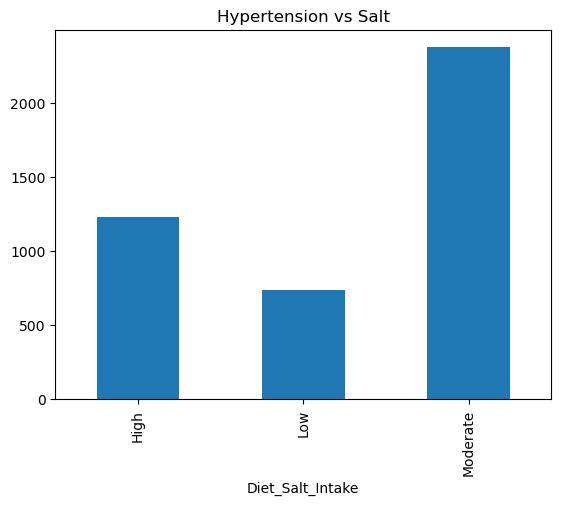

In [77]:
df4 = data.groupby("Diet_Salt_Intake")['Is_Hypertensive'].sum()
df4.plot(kind="bar")
plt.title("Hypertension vs Salt");

In [78]:
Feature_cols=["Systolic_BP_mmHg", "BMI", "Age", "Diastolic_BP_mmHg", "Pulse_Pressure_mmHg", "Mean_Arterial_Pressure", "Heart_Rate_bpm", "Country_HTN_Prevalence_pct"]
y= data['Is_Hypertensive']
X = data[Feature_cols]
#y = data[Target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.2, random_state=42)


In [79]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)